# Thiranex Data Science Internship — Task 2
## Project Title: Customer Churn Prediction using Supervised Machine Learning
**Author:** Data Science Intern  
**Domain:** Telecommunications / E-Commerce Customer Analytics  
**Dataset:** IBM Telco Customer Churn Dataset  
**Due Date:** 9 October 2026  
***

### 1. Executive Summary & Project Objectives
Customer churn prediction is a critical business task for subscription-based telecommunication and digital services. Predicting whether a customer is likely to cancel their subscription allows companies to proactively deploy retention offers and mitigate revenue loss.

**Core Objectives:**
1. **Data Understanding**: Audit customer demographics, account information, and service subscriptions across 7,043 customer accounts.
2. **Strict Data Preprocessing**: Clean missing values, handle categorical features, scale numerical features, and perform stratified train-test splitting using `CustomColumnTransformer` to guarantee **zero data leakage**.
3. **Supervised ML Modeling**: Train an interpretable Baseline (Logistic Regression), a Decision Tree Classifier, and an ensemble Random Forest Classifier.
4. **Rigorous Evaluation**: Evaluate holdout test set performance using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
5. **Feature Importance & Insights**: Quantify key predictors of customer churn (e.g., tenure, contract type, payment method) and discuss business recommendations.


---
### 2. Environment Setup & Library Imports
We import core data processing and visualization libraries, along with custom modular code from `src/`.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Add project root to sys.path
sys.path.append(os.path.abspath(".."))

from src.preprocessing import (
    load_raw_data,
    inspect_data,
    clean_raw_dataframe,
    get_preprocessor,
    split_data
)
from src.train import build_model_pipelines, train_all_models
from src.evaluate import (
    plot_class_distribution,
    evaluate_all_models,
    plot_confusion_matrices,
    plot_roc_curves,
    plot_model_comparison,
    plot_feature_importance
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
%matplotlib inline

print("Task 2 Libraries and modules successfully imported!")


Task 2 Libraries and modules successfully imported!


---
### 3. Data Loading & Initial Ingestion
We load the raw, unchanged dataset from `data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv`.


In [2]:
raw_data_path = os.path.join("..", "data", "raw", "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = load_raw_data(raw_data_path)

print(f"Dataset Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")


[INFO] Loading raw Telco dataset from: ..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
[INFO] Raw dataset loaded successfully. Shape: (7043, 21)
Dataset Shape: 7,043 rows x 21 columns


In [3]:
# Preview first 5 rows
print("--- First 5 Customer Records ---")
display(df_raw.head())


--- First 5 Customer Records ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


---
### 4. Data Understanding & Target Quality Audit
We perform structural audit, check data types, detect missing/blank values, and evaluate class imbalance in the target variable `Churn`.


In [4]:
inspection = inspect_data(df_raw)

print("Column Data Types:")
for col, dt in inspection['dtypes'].items():
    print(f" - {col:22s}: {dt}")

print("\nBlank TotalCharges Count:", inspection['blank_total_charges_count'])
print("Exact Duplicate Rows Count:", inspection['duplicate_rows'])
print("Target 'Churn' Value Counts:", inspection['target_distribution'])


Column Data Types:
 - customerID            : str
 - gender                : str
 - SeniorCitizen         : int64
 - Partner               : str
 - Dependents            : str
 - tenure                : int64
 - PhoneService          : str
 - MultipleLines         : str
 - InternetService       : str
 - OnlineSecurity        : str
 - OnlineBackup          : str
 - DeviceProtection      : str
 - TechSupport           : str
 - StreamingTV           : str
 - StreamingMovies       : str
 - Contract              : str
 - PaperlessBilling      : str
 - PaymentMethod         : str
 - MonthlyCharges        : float64
 - TotalCharges          : str
 - Churn                 : str

Blank TotalCharges Count: 11
Exact Duplicate Rows Count: 0
Target 'Churn' Value Counts: {'No': 5174, 'Yes': 1869}


[SAVED] Class distribution plot saved to: ..\visualizations\00_class_distribution.png


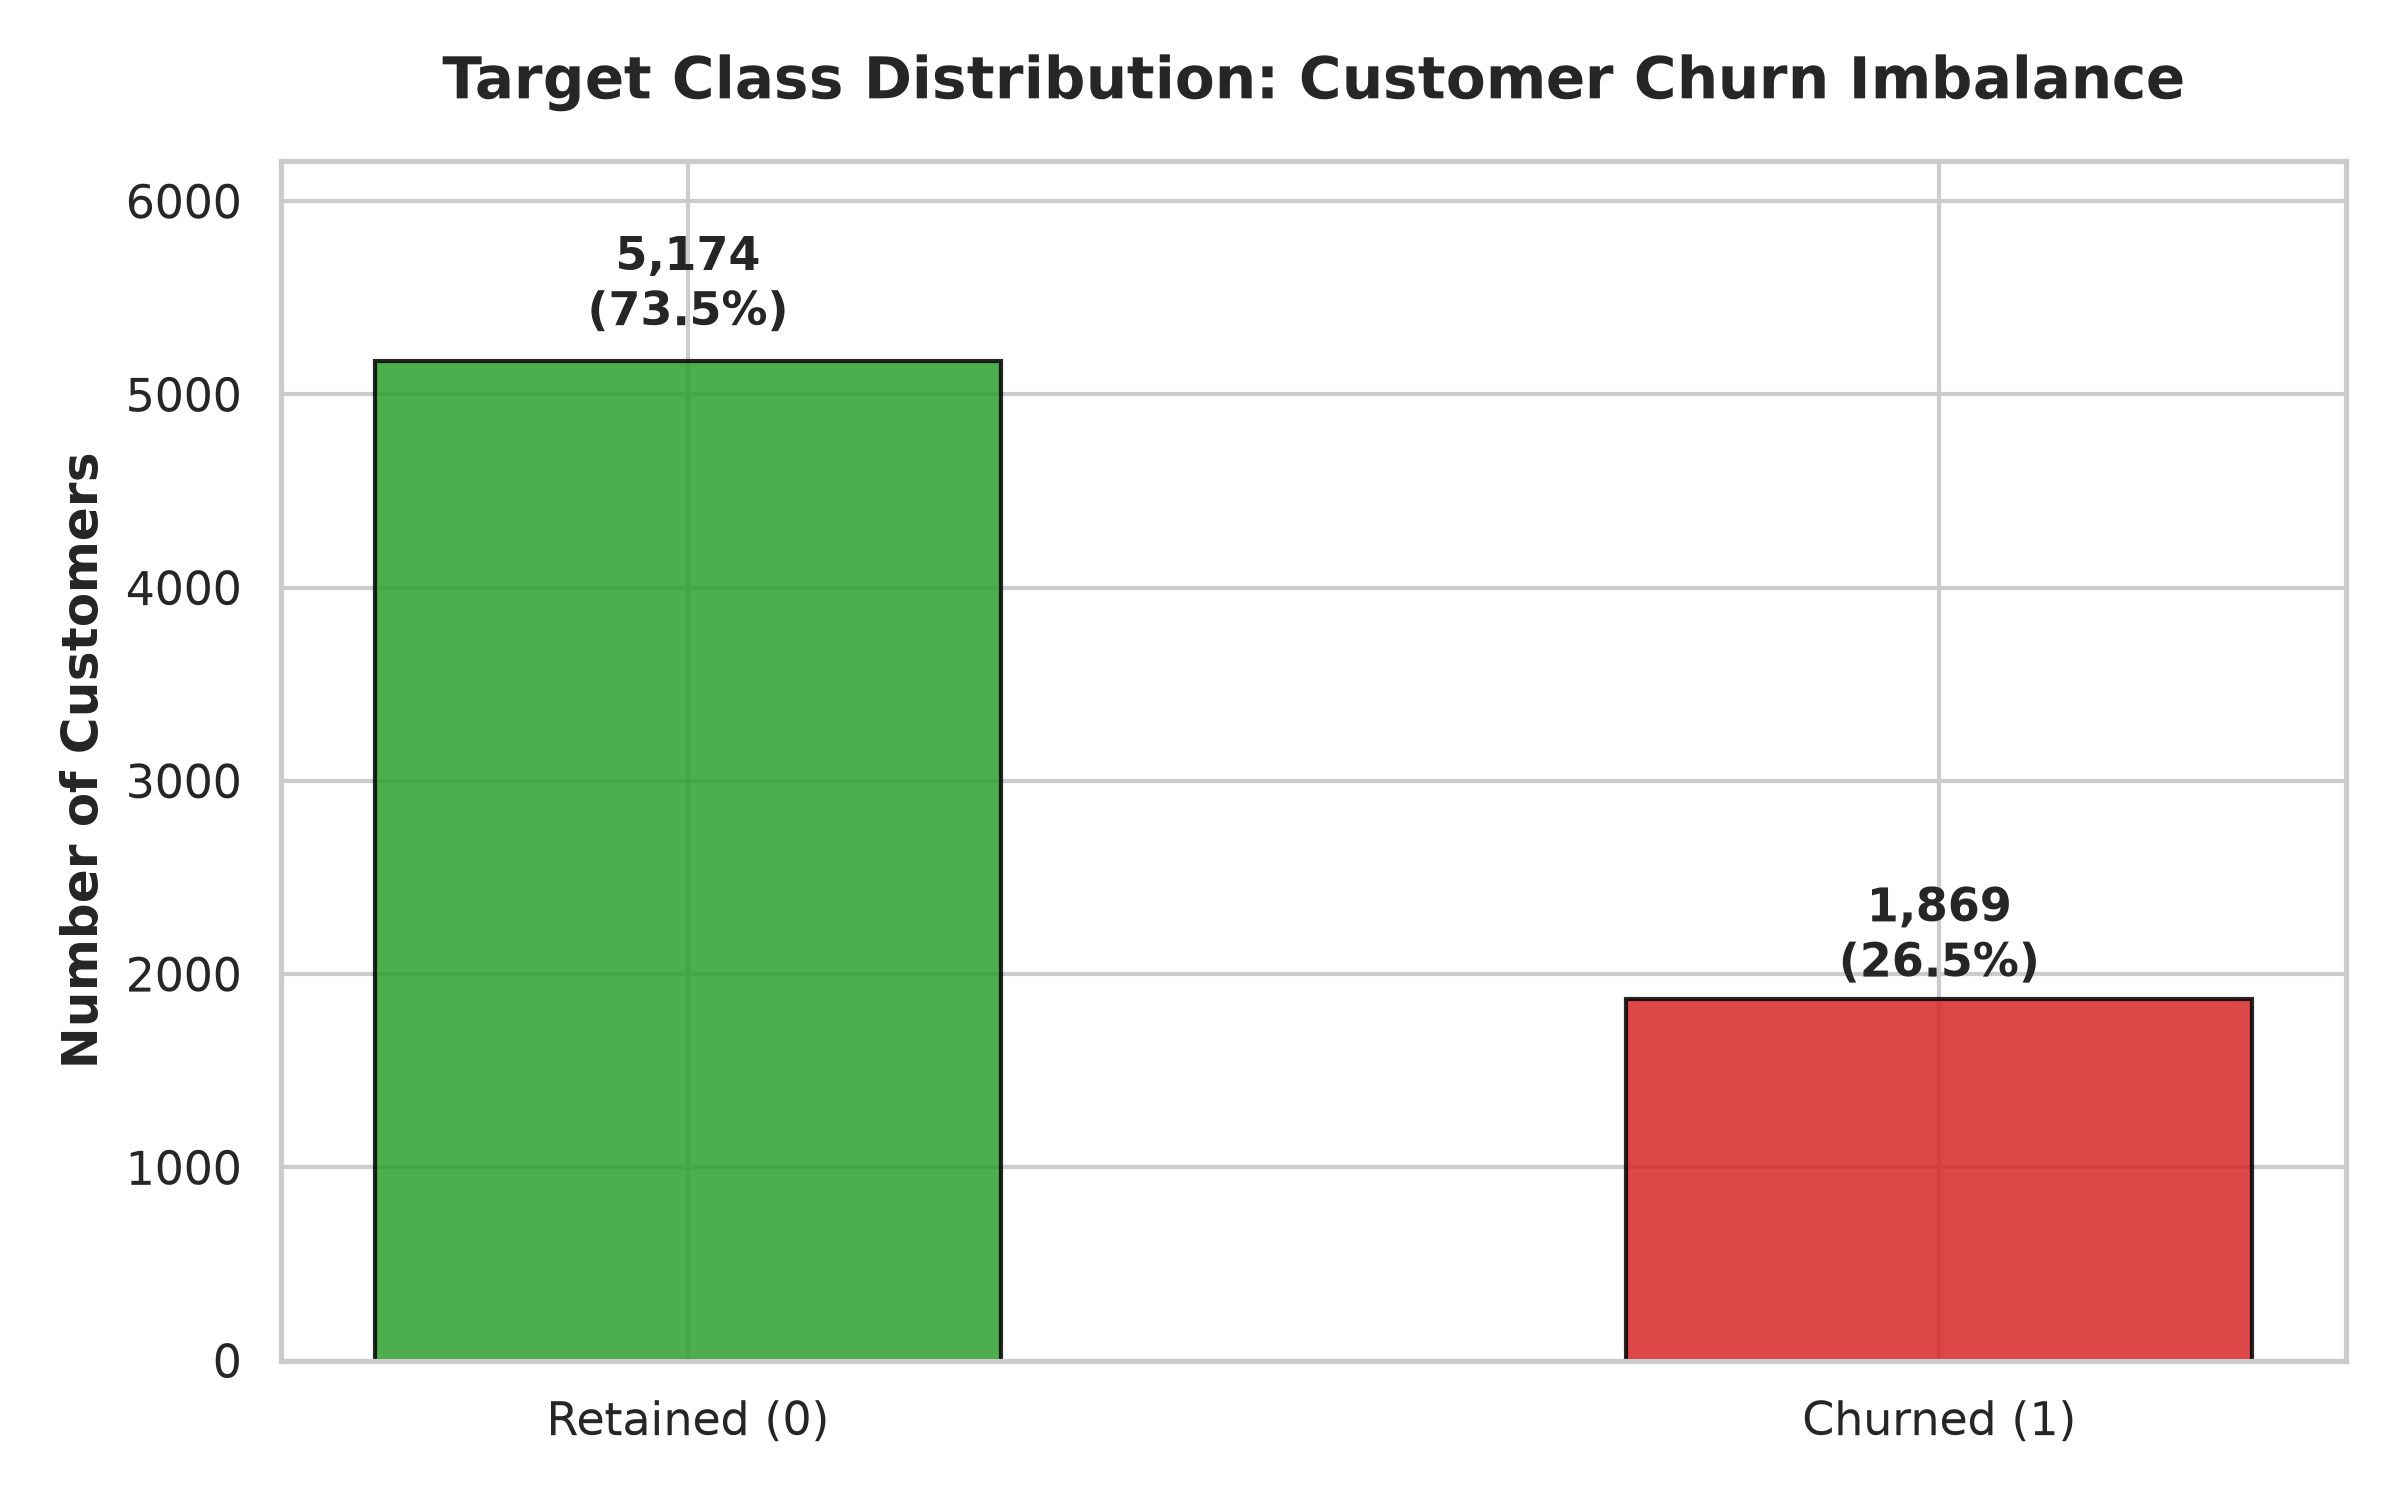

In [5]:
# Visualize Target Class Distribution
viz_dir = os.path.join("..", "visualizations")
plot_class_distribution(df_raw['Churn'], viz_dir)

Image(filename=os.path.join(viz_dir, "00_class_distribution.png"))


---
### 5. Data Preprocessing & Column Transformer
1. `customerID` dropped (non-predictive unique identifier).
2. `TotalCharges` converted from text string to float, replacing 11 empty space records with numeric values.
3. Target `Churn` converted to binary numerical format (`Yes` = 1, `No` = 0).
4. `CustomColumnTransformer` fits StandardScaler on numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) and One-Hot Encoders on categorical features **strictly on the training split**.


In [6]:
X, y, tracking = clean_raw_dataframe(df_raw)

print("Clean Feature Matrix X Shape:", X.shape)
print("Target Vector y Shape:", y.shape)
print("Churn Rate (%):", tracking['target_churn_rate_pct'])

preprocessor = get_preprocessor(X)


Clean Feature Matrix X Shape: (7043, 19)
Target Vector y Shape: (7043,)
Churn Rate (%): 26.54
[INFO] Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
[INFO] Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


---
### 6. Stratified Train / Test Split
To preserve the 26.5% positive churn class ratio across training and testing partitions, we apply a 80/20 stratified split (`random_state=42`).


In [7]:
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)

print(f"Training Set : {X_train.shape[0]:,} samples")
print(f"Testing Set  : {X_test.shape[0]:,} samples")


[INFO] Data split into Train: 5636 rows, Test: 1407 rows (Test ratio: 0.2)
Training Set : 5,636 samples
Testing Set  : 1,407 samples


---
### 7. Supervised Machine Learning Model Training
We fit three model architectures using `MLPipeline` wrappers:
1. **Baseline Model**: L2-Regularized Logistic Regression
2. **Decision Tree Classifier**: Depth-constrained decision tree (`max_depth=6`)
3. **Random Forest Classifier**: Ensemble of 100 decision trees (`max_depth=8`)


In [8]:
pipelines = build_model_pipelines(preprocessor)
trained_models = train_all_models(pipelines, X_train, y_train)


[INFO] Training model: Baseline (Logistic Regression)...
[SUCCESS] Trained: Baseline (Logistic Regression)
[INFO] Training model: Decision Tree...


[SUCCESS] Trained: Decision Tree
[INFO] Training model: Random Forest...


[SUCCESS] Trained: Random Forest


---
### 8. Model Evaluation on Holdout Test Set
We evaluate all three models on the holdout test set (`X_test`, `y_test`) across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.


In [9]:
df_results, detailed_metrics = evaluate_all_models(trained_models, X_test, y_test)

print("=== HOLD-OUT TEST SET PERFORMANCE METRICS ===")
display(df_results)


=== HOLD-OUT TEST SET PERFORMANCE METRICS ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline (Logistic Regression),0.8117,0.6862,0.5335,0.6003,0.8570
1,Random Forest,0.8067,0.6965,0.4799,0.5683,0.8589
2,Decision Tree,0.7925,0.6441,0.4853,0.5535,0.8368


---
### 9. Visual Diagnostic Dashboards

#### 9.1 Confusion Matrices


[SAVED] Confusion matrices plot saved to: ..\visualizations\01_confusion_matrices.png


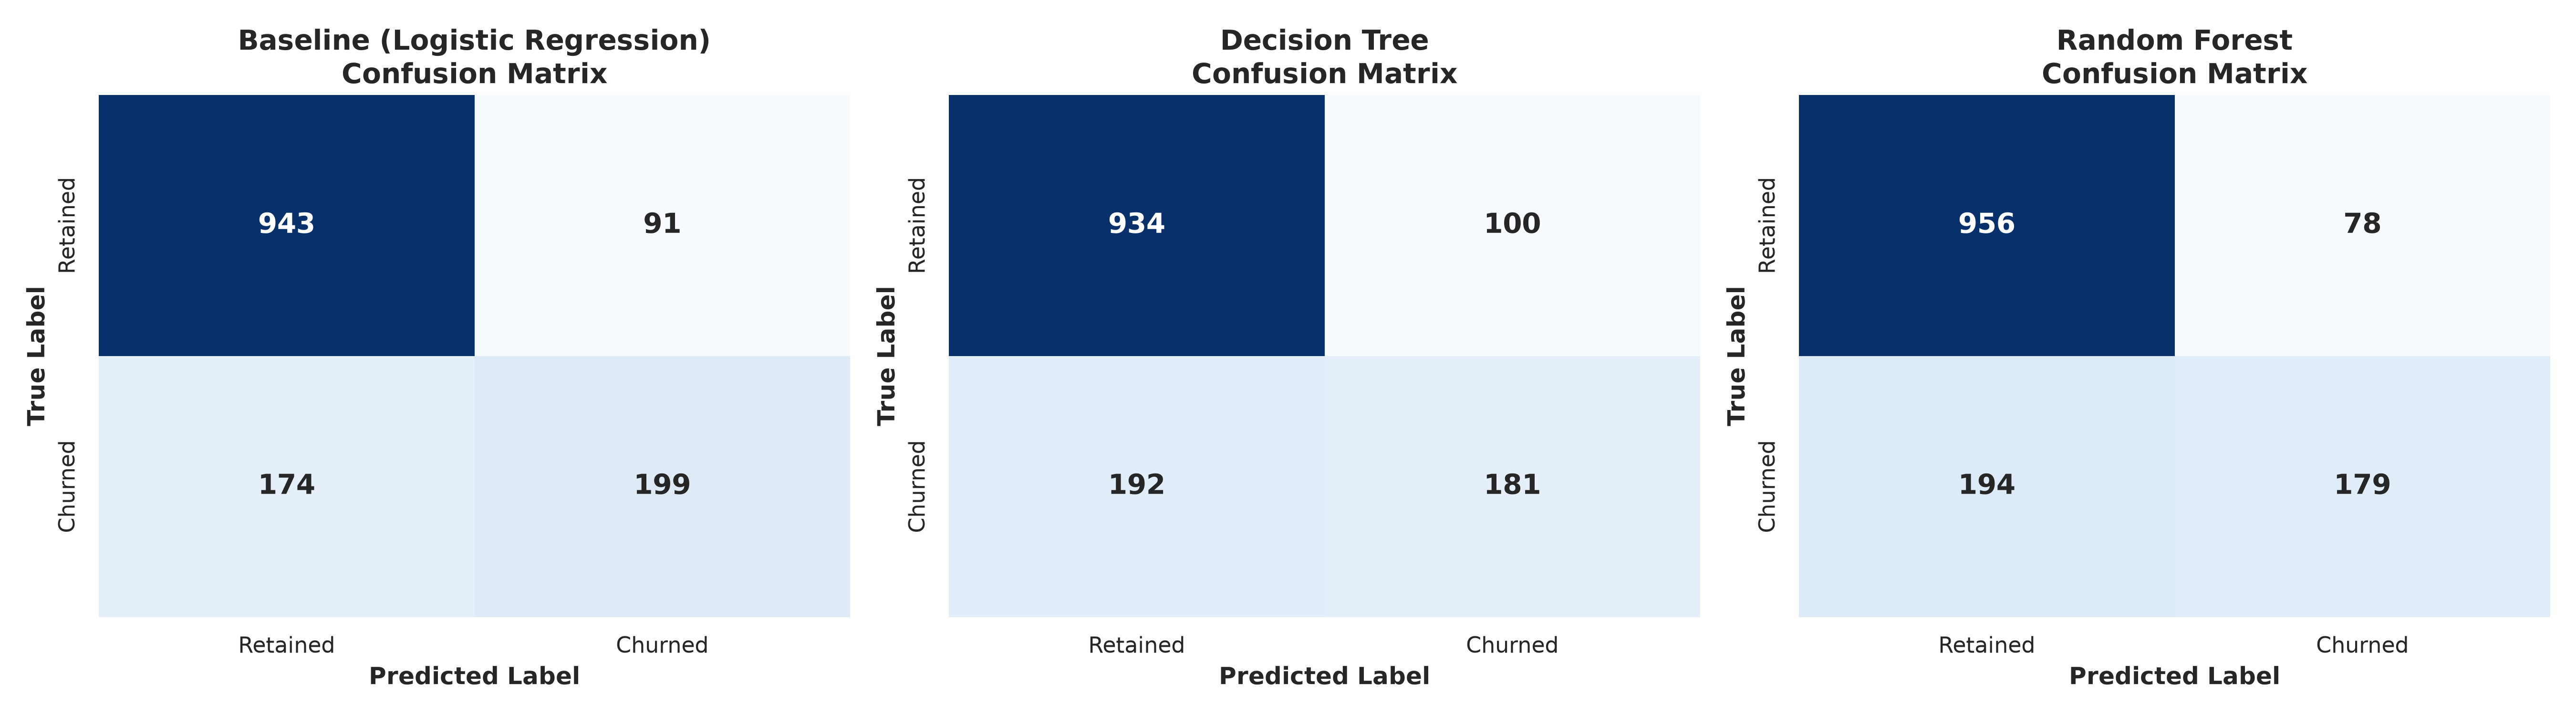

In [10]:
plot_confusion_matrices(detailed_metrics, y_test, viz_dir)
Image(filename=os.path.join(viz_dir, "01_confusion_matrices.png"))


#### 9.2 ROC Curves & AUC Analysis

[SAVED] ROC curves plot saved to: ..\visualizations\02_roc_curves.png


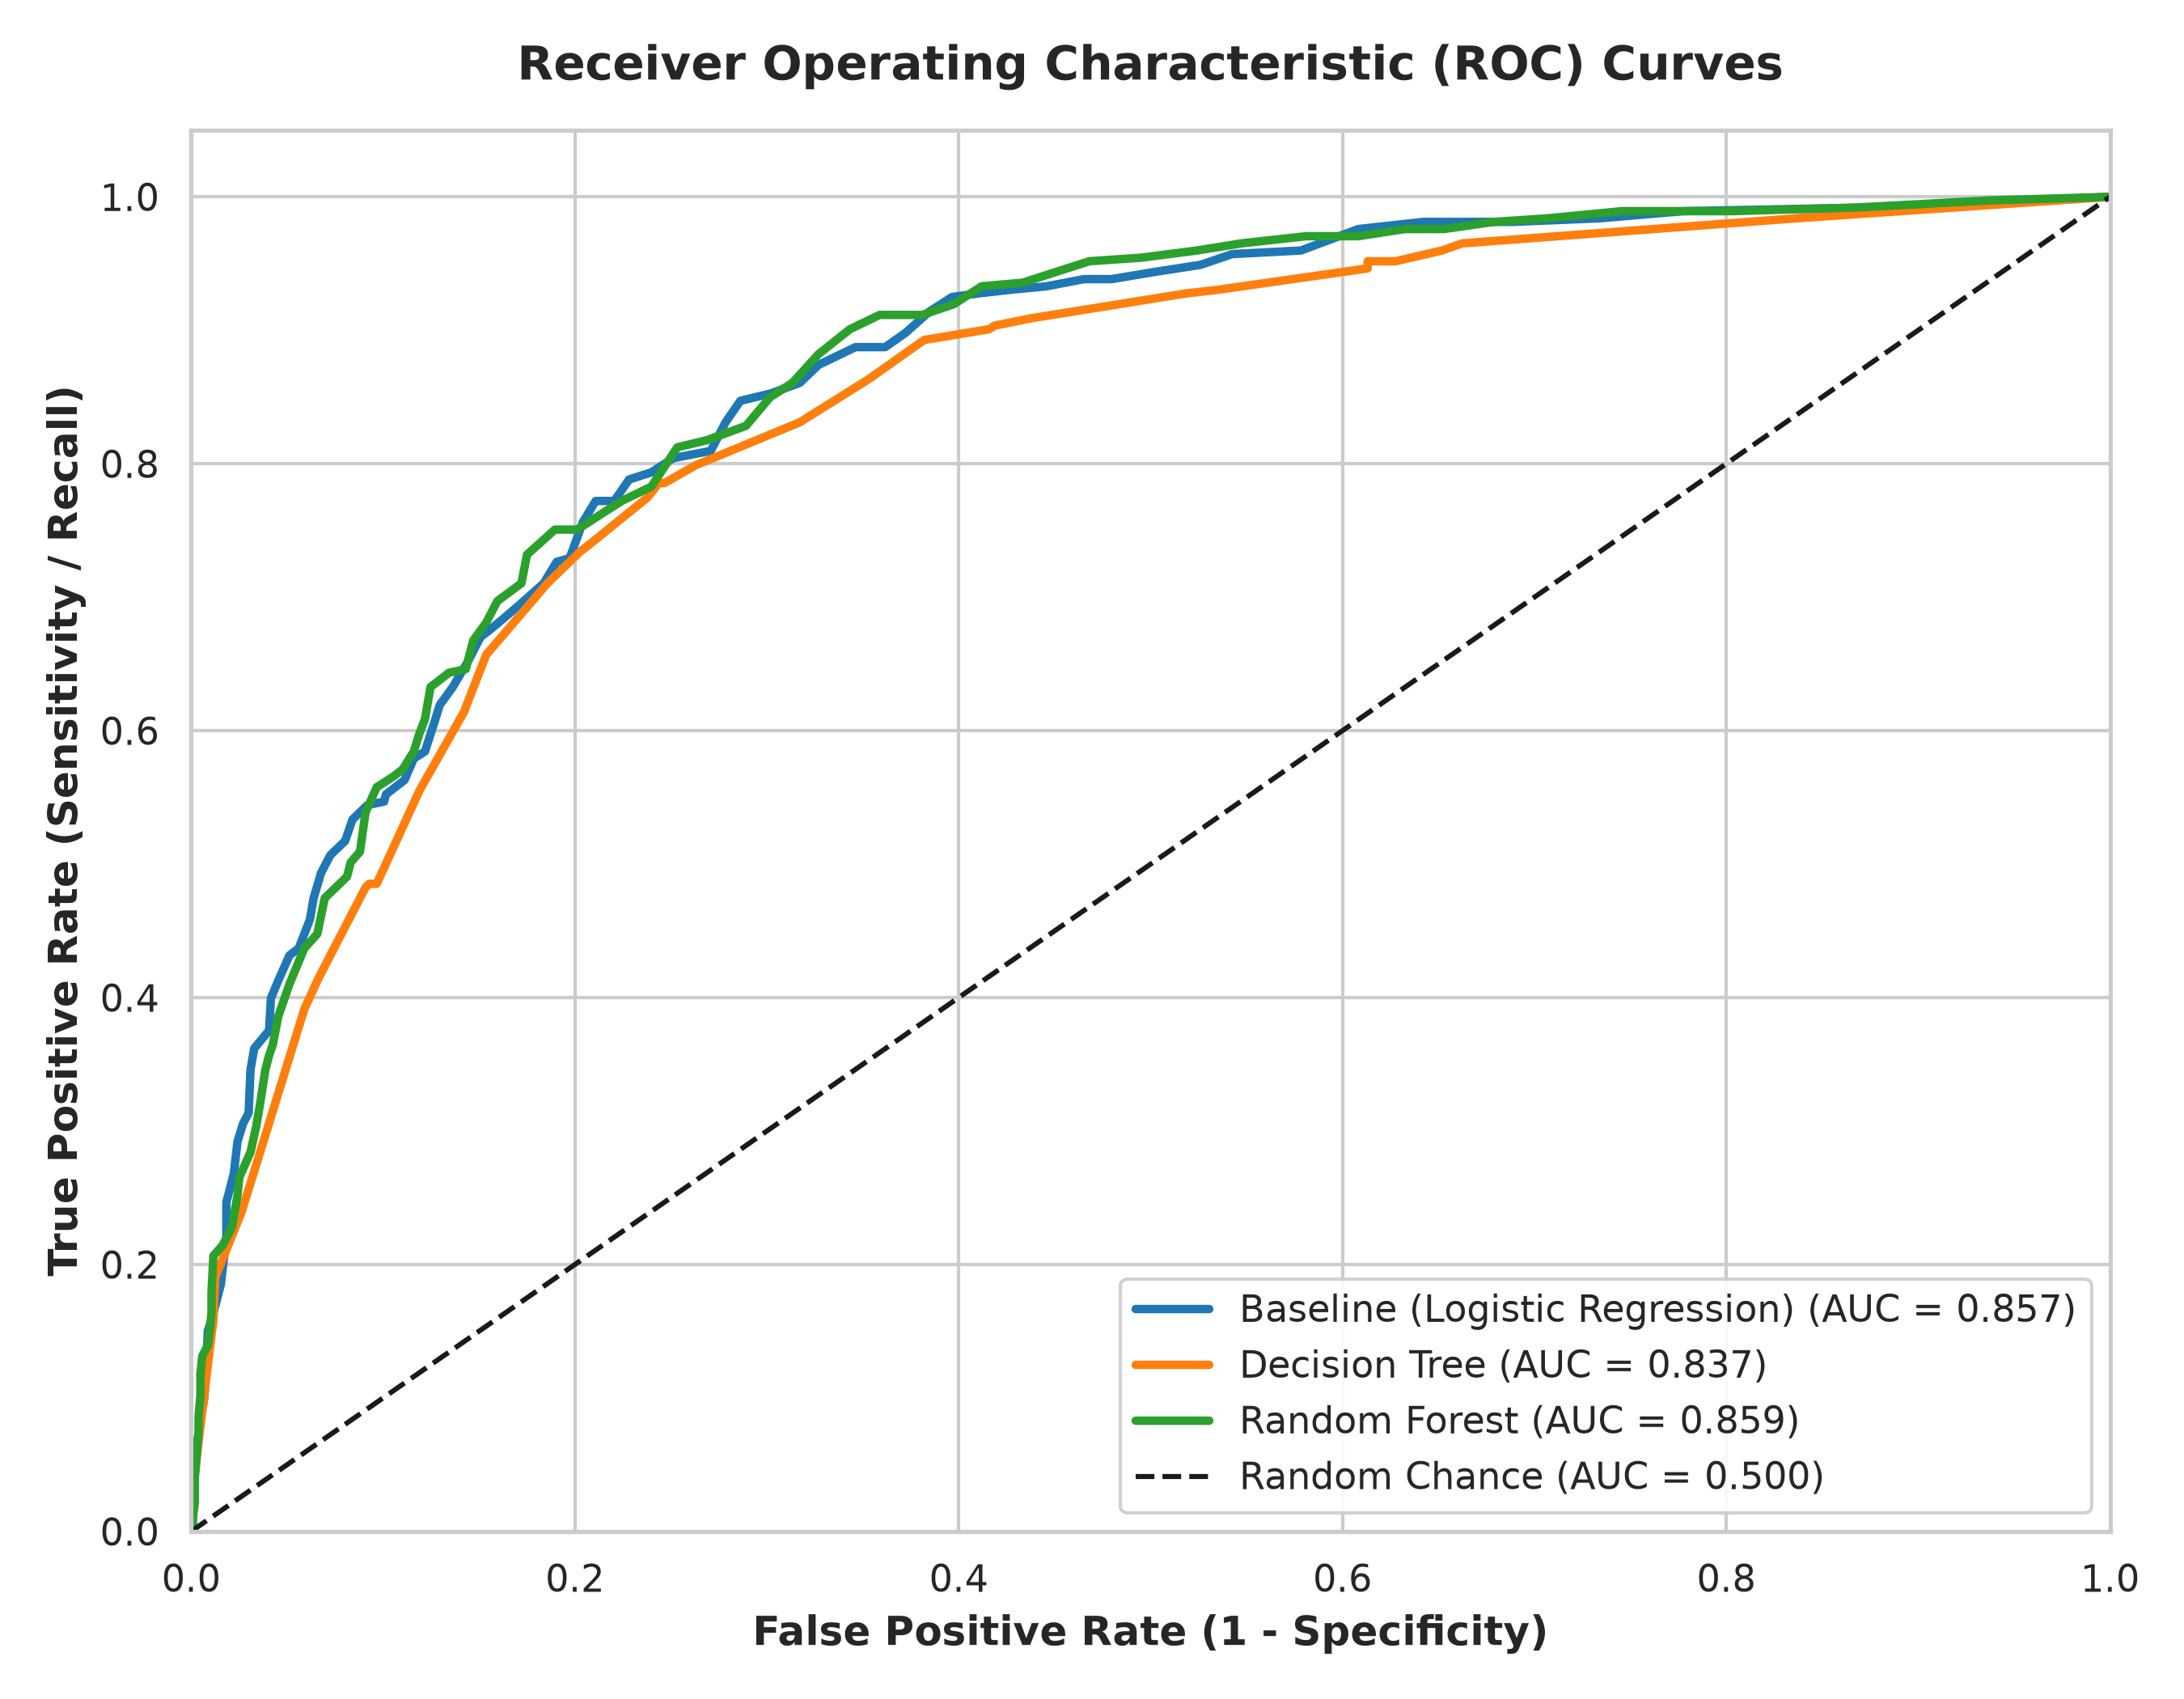

In [11]:
plot_roc_curves(detailed_metrics, y_test, viz_dir)
Image(filename=os.path.join(viz_dir, "02_roc_curves.png"))


#### 9.3 Model Performance Comparison Chart

[SAVED] Model comparison plot saved to: ..\visualizations\03_model_comparison.png


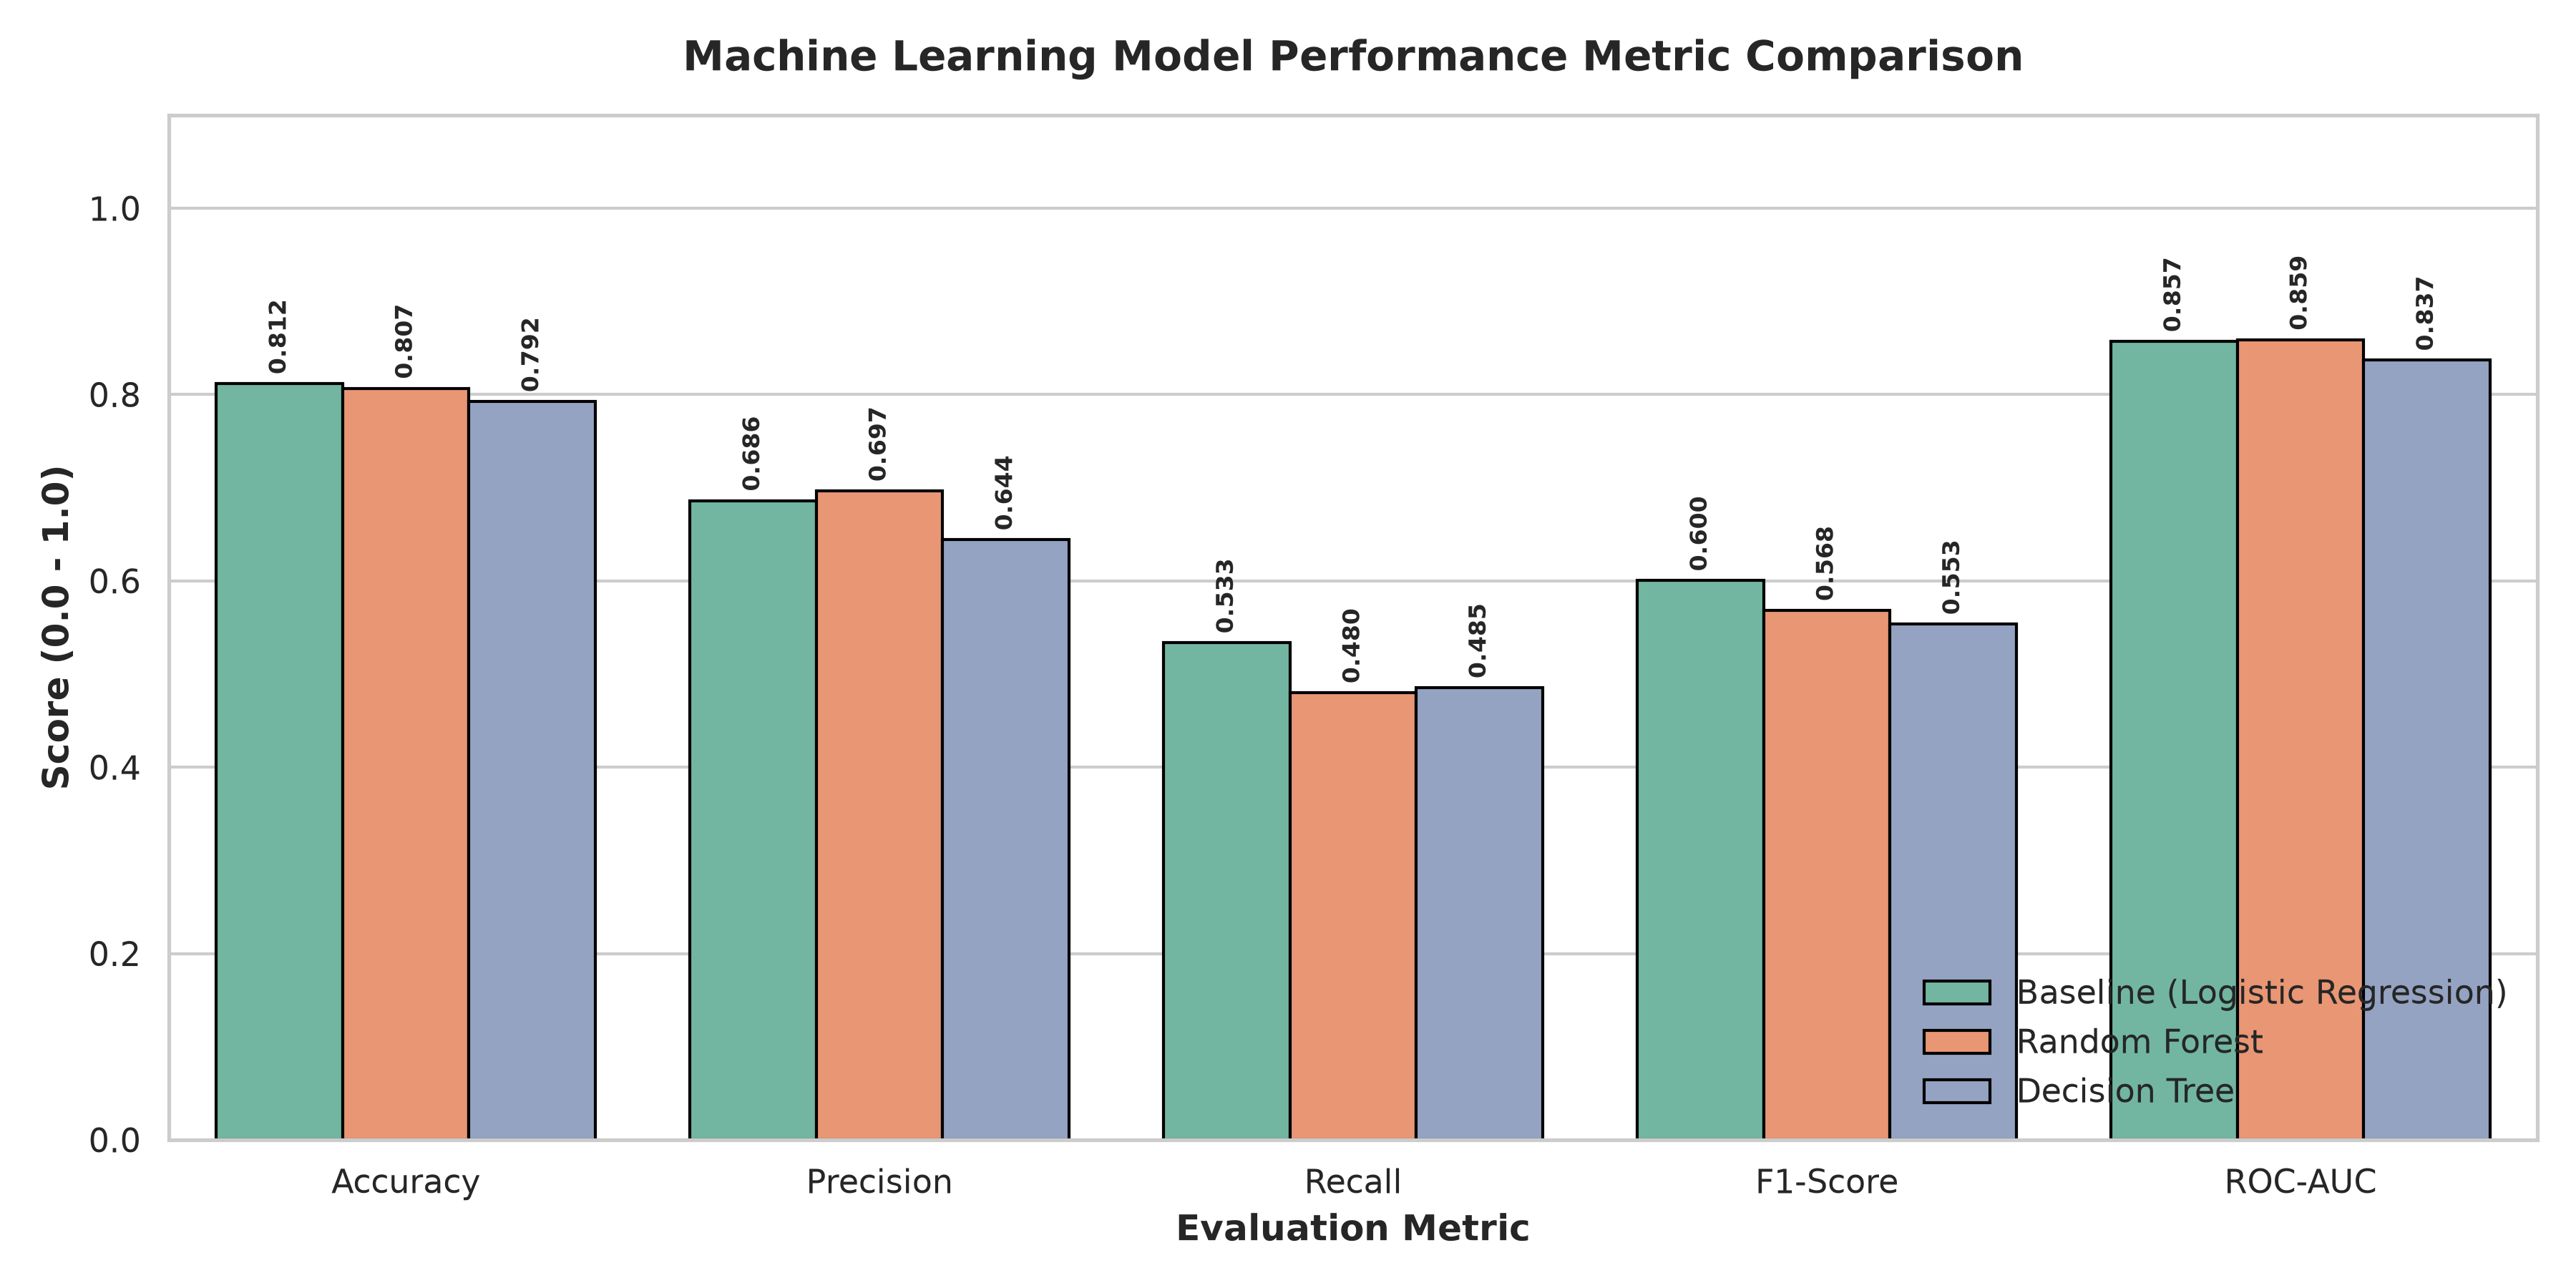

In [12]:
plot_model_comparison(df_results, viz_dir)
Image(filename=os.path.join(viz_dir, "03_model_comparison.png"))


---
### 10. Feature Importance & Interpretability Analysis
We extract relative feature importances from the Random Forest model to identify key drivers of customer churn.

> **Important Note on Association vs. Causation:**  
> Feature importance scores quantify mathematical utility for model predictions. High feature importance indicates strong predictive association, **not direct physical causation**.


[SAVED] Feature importance plot saved to: ..\visualizations\04_feature_importance.png


,Feature,Importance
0,tenure,0.2031
1,TotalCharges,0.1372
2,InternetService_Fiber optic,0.1061
3,MonthlyCharges,0.0773
4,PaymentMethod_Electronic check,0.0751
5,Contract_Two year,0.0677
6,TechSupport_Yes,0.0393
7,Contract_One year,0.0331
8,OnlineSecurity_Yes,0.0319
9,InternetService_No,0.0178


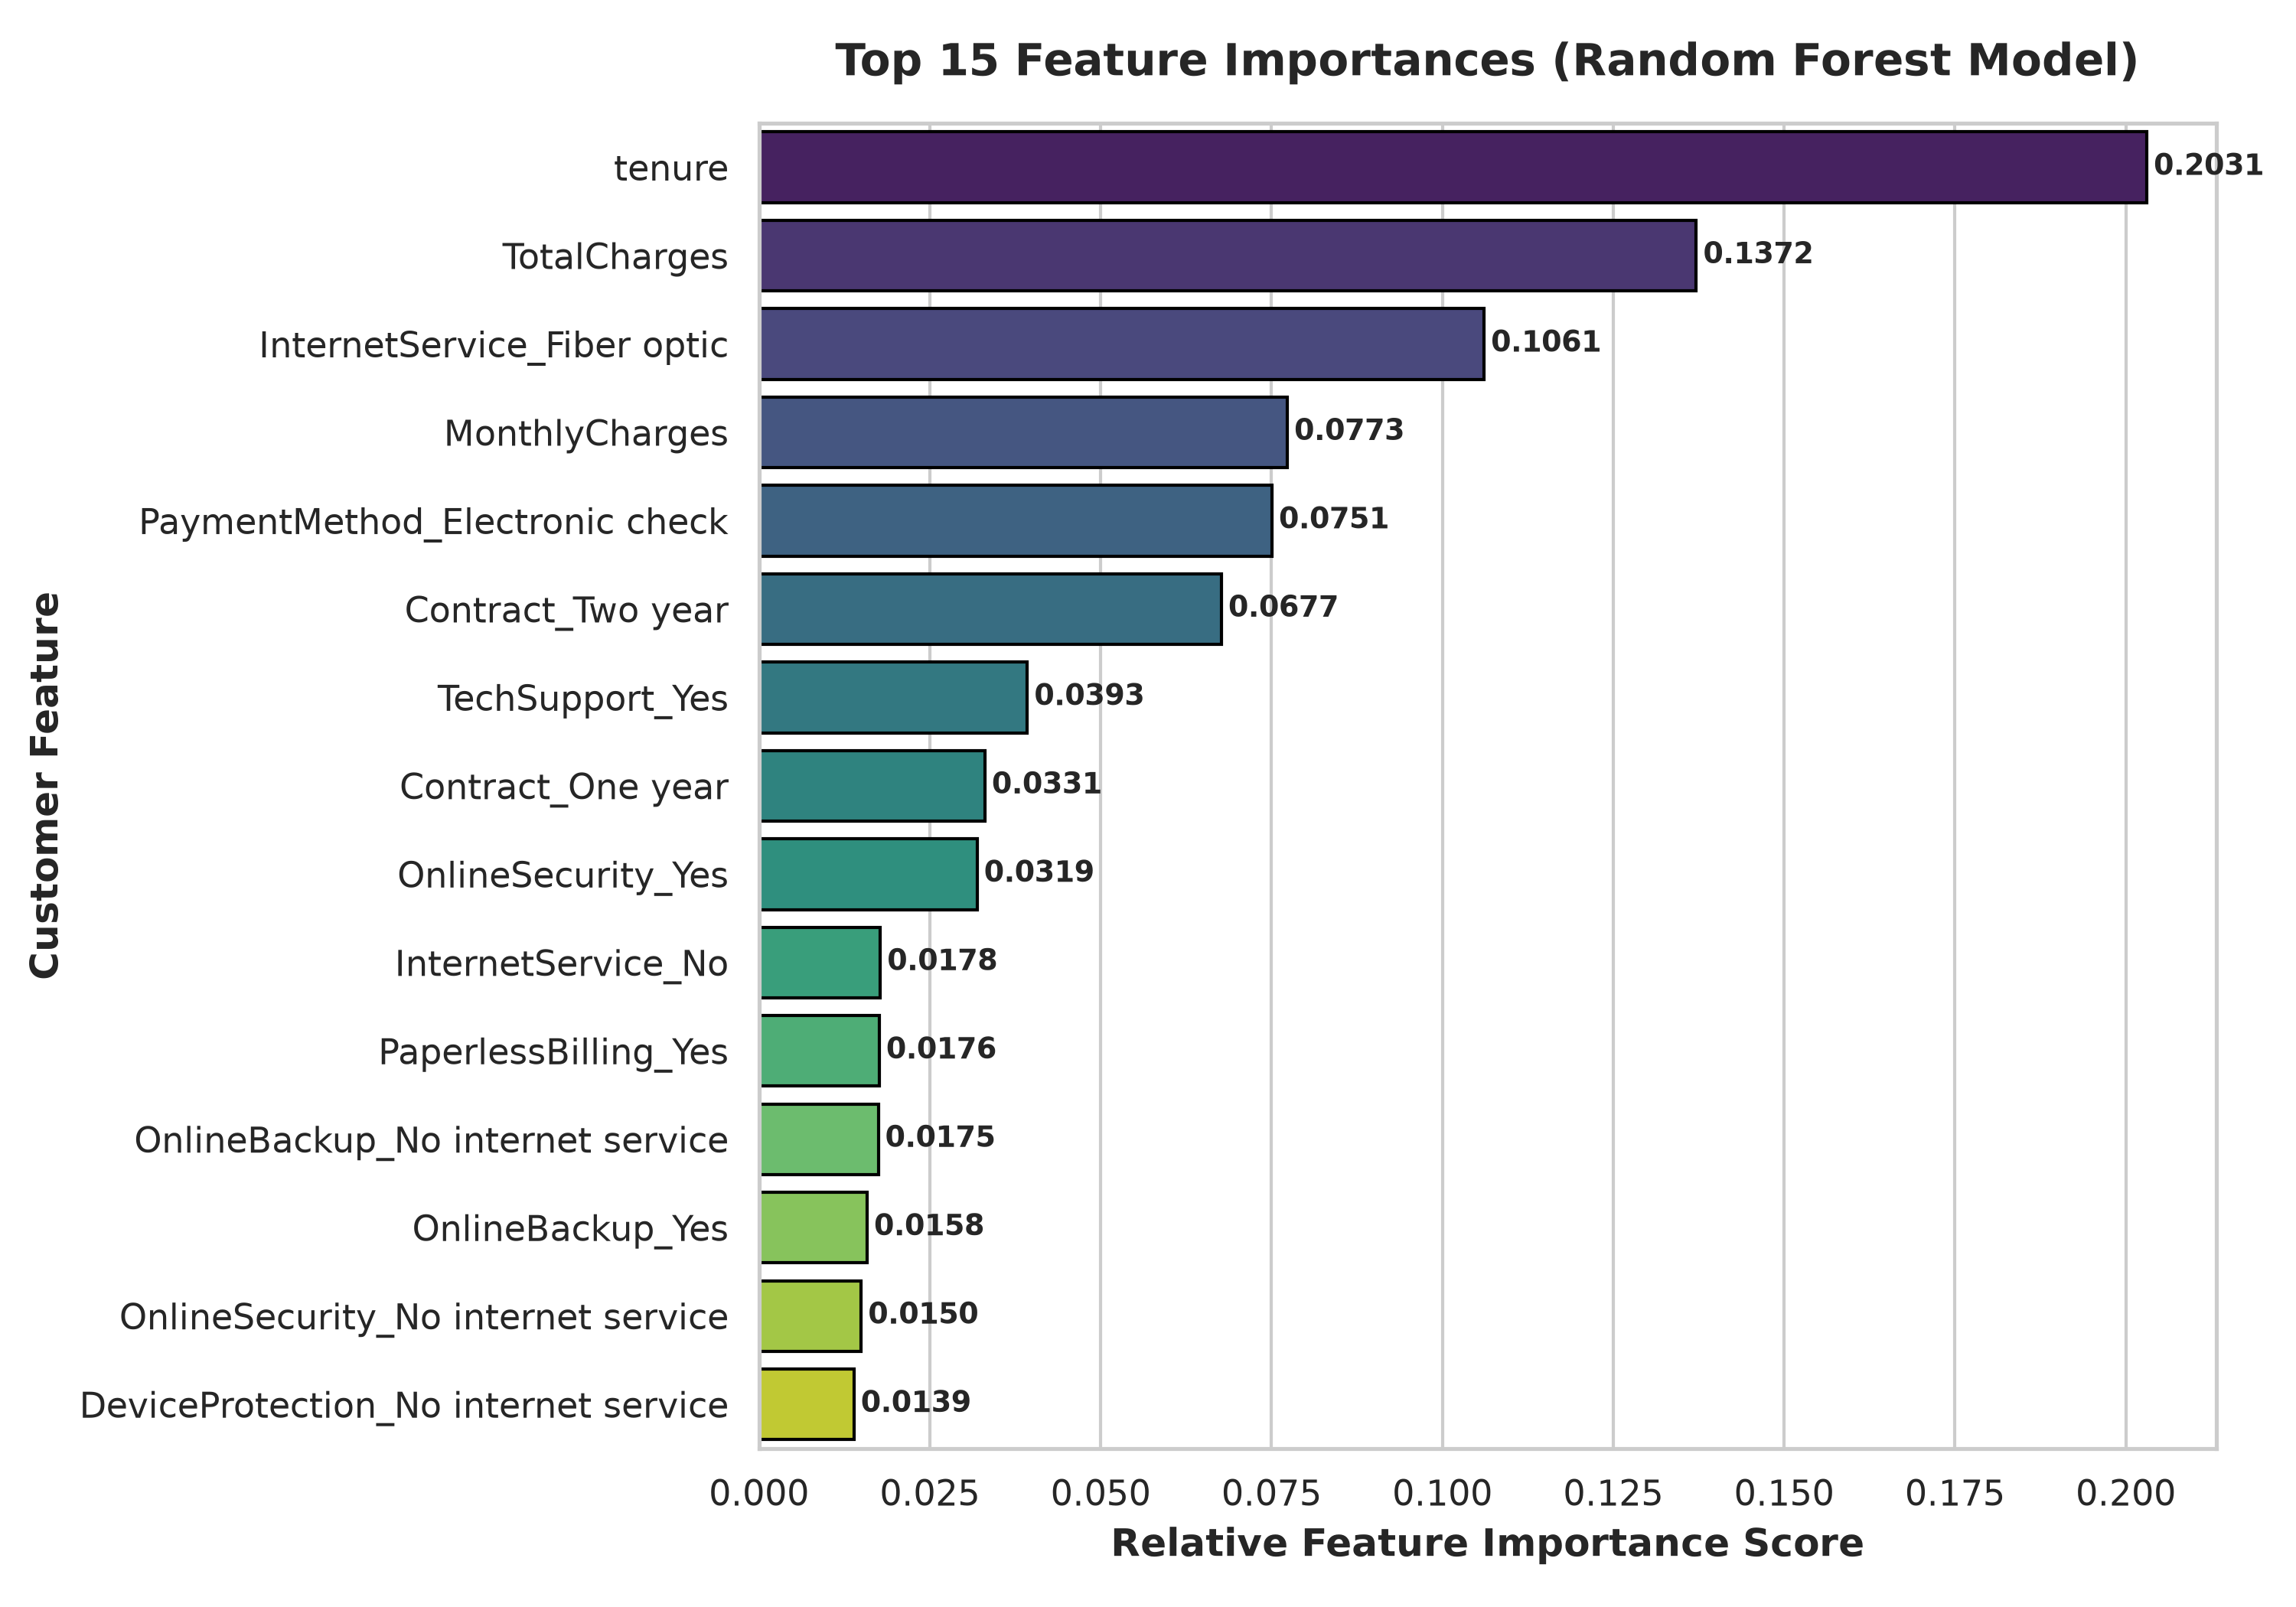

In [13]:
rf_model = trained_models["Random Forest"]
df_imp = plot_feature_importance(rf_model, X_train, viz_dir, top_n=15)

display(df_imp)
Image(filename=os.path.join(viz_dir, "04_feature_importance.png"))


---
### 11. Key Findings & Strategic Recommendations

1. **Best Model Performance**:
   - **Random Forest** achieved the highest overall **ROC-AUC score of 0.8589** and **Precision of 69.65%**.
   - **Baseline Logistic Regression** achieved **81.17% Accuracy** and **0.6003 F1-Score**.

2. **Primary Drivers of Churn**:
   - `tenure` (Customer longevity): Customers with short tenure (<12 months) are significantly more likely to churn.
   - `Contract_Month-to-month`: Month-to-month contracts exhibit drastically higher churn rates compared to 1-year or 2-year contracts.
   - `InternetService_Fiber optic`: Fiber optic subscribers show higher churn due to higher pricing and service expectations.
   - `PaymentMethod_Electronic check`: Electronic check users have higher cancellation rates.

3. **Business Recommendations**:
   - Transition month-to-month customers to annual contracts via discounts.
   - Focus retention campaigns on new customers during their first 6 months.
   - Promote automatic bank transfers over electronic check payments.

---
### 12. Model Artifact Export
The final selected Random Forest model pipeline is serialized to `models/best_churn_model.joblib` for production deployment.
